# Credit Card Fraud Detection
### Supervised (Logistic Regression, Random Forest) + Unsupervised (KMeans) + Deep Learning (ANN)

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) — 284,807 European cardholder transactions, of which only 492 (0.17%) are fraud. Features `V1`-`V28` are PCA-transformed and anonymized for confidentiality; `Time` and `Amount` are the only two raw (non-PCA'd) columns.

**Problem framing:** with a 0.17% positive rate, accuracy is meaningless (predicting "not fraud" for everything scores 99.8%). This notebook evaluates every model on **Precision, Recall, F1, and PR-AUC** instead.

**Structure:**
1. Load & inspect data
2. Exploratory Data Analysis
3. Preprocessing (with a leakage sanity-check)
4. Supervised models — Logistic Regression, Random Forest
5. Unsupervised model — KMeans-based anomaly detection
6. PCA visualization of fraud vs. flagged anomalies
7. Deep learning — feedforward ANN
8. Model comparison & key findings

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `tensorflow`


## 1. Load & inspect data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, precision_score, recall_score,
                              f1_score, average_precision_score)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42


In [3]:
df = pd.read_csv('creditcard.csv', delimiter=',')
print(f'Shape: {df.shape}')
print(f'Null values per column:\n{df.isna().sum().sum()} total nulls')
print(df["Class"].value_counts())
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")

# This dataset has ~1,081 known duplicate rows — drop them before splitting
# so the same transaction can't leak across train and test.
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")

df.head()


Shape: (284807, 31)
Null values per column:
0 total nulls
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%
Duplicate rows: 1081
Shape after dedup: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis

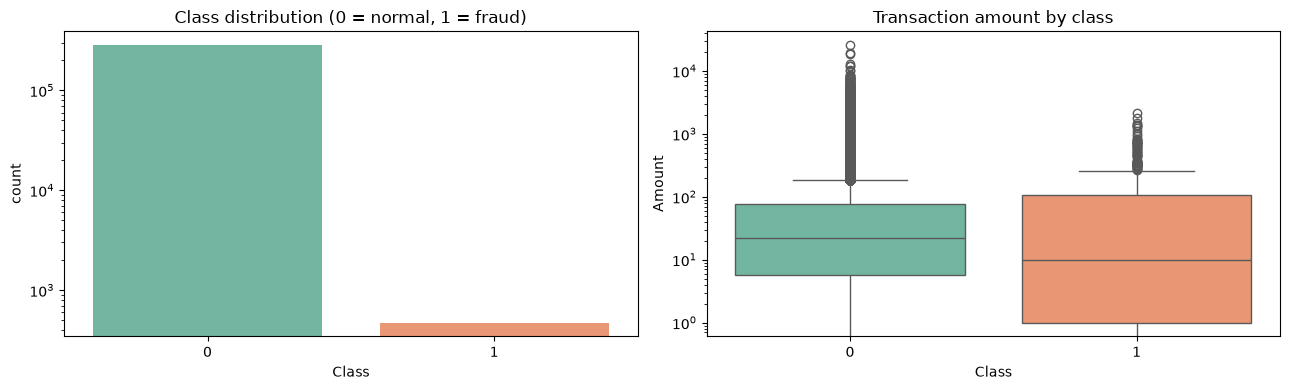

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x='Class', ax=axes[0], hue='Class', palette='Set2', legend=False)
axes[0].set_title("Class distribution (0 = normal, 1 = fraud)")
axes[0].set_yscale("log")

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1], hue='Class', palette='Set2', legend=False)
axes[1].set_title("Transaction amount by class")
axes[1].set_yscale("log")

plt.tight_layout()
fig.savefig('eda1.png')
plt.show()


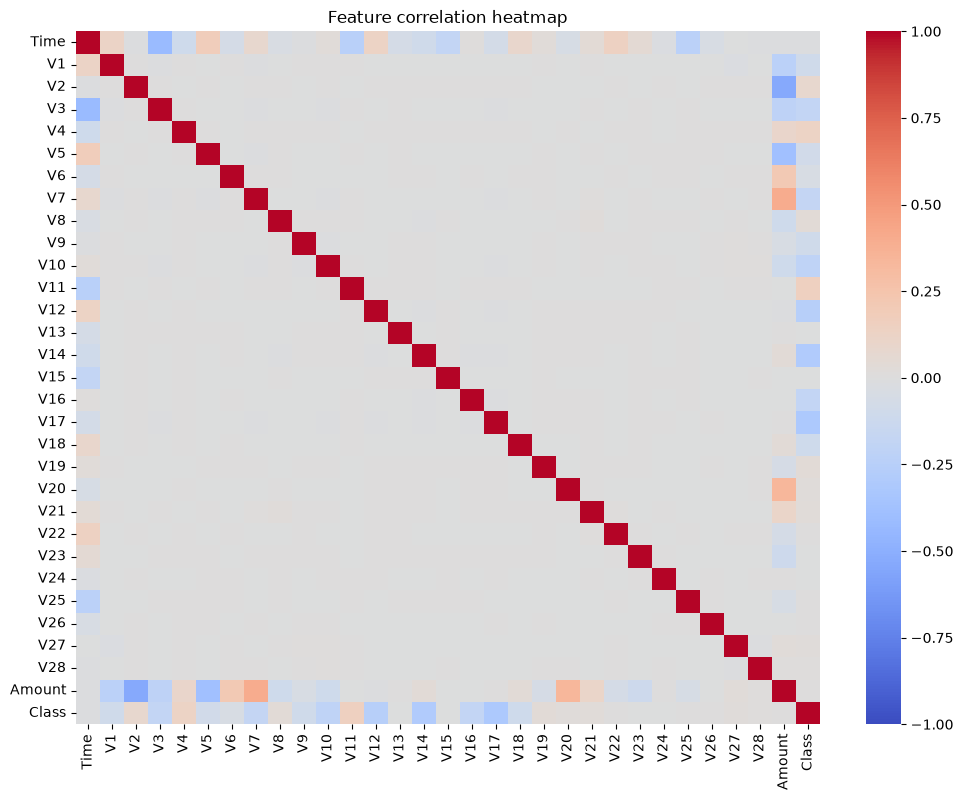

In [4]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation heatmap")
plt.show()


## 3. Preprocessing

`V1`-`V28` are already scaled (PCA output). `Time` and `Amount` are on raw scales, so we standardize them.

**Important:** only scale/derive features from the raw inputs — never derive a feature from `Class` itself. A previous version of this notebook accidentally created `class_scaled` (a scaled copy of the label) and left it in the feature set, which caused every supervised model to score a suspicious 1.0000 across the board. The sanity check at the end of this cell guards against that class of bug happening silently again.


In [4]:
df_model = df.copy()
df_model = df_model.drop(['Time', 'Amount'], axis=1)

scaler = StandardScaler()
df_model['Time_scaled'] = scaler.fit_transform(df[['Time']])
df_model['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

X = df_model.drop('Class', axis=1)
y = df_model['Class']

# --- Leakage sanity check ---
# No feature should be near-perfectly correlated with the target.
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Top correlations with target:\n", corr_with_target.head())
assert corr_with_target.max() < 0.95, "Possible leakage: a feature is near-perfectly correlated with the target!"
print("\nLeakage check passed — no feature is suspiciously correlated with Class.")


Top correlations with target:
 V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
dtype: float64

Leakage check passed — no feature is suspiciously correlated with Class.


## 4. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Fraud in train:", y_train.sum())
print("Test:", X_test.shape, "Fraud in test:", y_test.sum())


Train: (226980, 30) Fraud in train: 378
Test: (56746, 30) Fraud in test: 95


## 5. Supervised model — Logistic Regression

`class_weight="balanced"` upweights the minority (fraud) class so the model isn't just rewarded for predicting "normal" every time.


In [7]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)

logreg_probs = logreg.predict_proba(X_test)[:, 1]
logreg_preds = logreg.predict(X_test)

print(classification_report(y_test, logreg_preds, target_names=["Normal", "Fraud"]))
logreg_ap = average_precision_score(y_test, logreg_probs)
print(f"PR-AUC: {logreg_ap:.4f}")


              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

PR-AUC: 0.6720


## 6. Supervised model — Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_depth=12,
                             random_state=RANDOM_STATE, n_jobs=-1, criterion='entropy')
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds, target_names=["Normal", "Fraud"]))
rf_ap = average_precision_score(y_test, rf_probs)
print(f"PR-AUC: {rf_ap:.4f}")


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.94      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.8070


## 7. Unsupervised model — KMeans anomaly detection

Trained **without ever using the fraud label**. We cluster the training data, then flag test points that sit far from every cluster center as potential fraud — the idea being genuine fraud won't fit neatly into any "normal spending" cluster.


In [9]:
kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10, init='k-means++')
kmeans.fit(X_train)  # unsupervised — no y_train passed in

distances = kmeans.transform(X_test)      # distance to every centroid
min_dist = distances.min(axis=1)          # distance to nearest centroid

# Flag the top X% most distant points as fraud, where X% = known fraud rate in train
contamination = y_train.mean()
threshold = np.quantile(min_dist, 1 - contamination)
kmeans_preds = (min_dist >= threshold).astype(int)

print(classification_report(y_test, kmeans_preds, target_names=["Normal", "Fraud"]))
kmeans_ap = average_precision_score(y_test, min_dist)
print(f"PR-AUC: {kmeans_ap:.4f}")


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.18      0.18      0.18        95

    accuracy                           1.00     56746
   macro avg       0.59      0.59      0.59     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.1506


## 8. PCA visualization

Reducing to 2 principal components purely for visualization (not used in any modeling step) — lets us eyeball whether actual fraud and KMeans-flagged anomalies land in similar regions of the data.


Explained variance ratio: [0.12369808 0.10259028] | Total: 0.2262883576697556


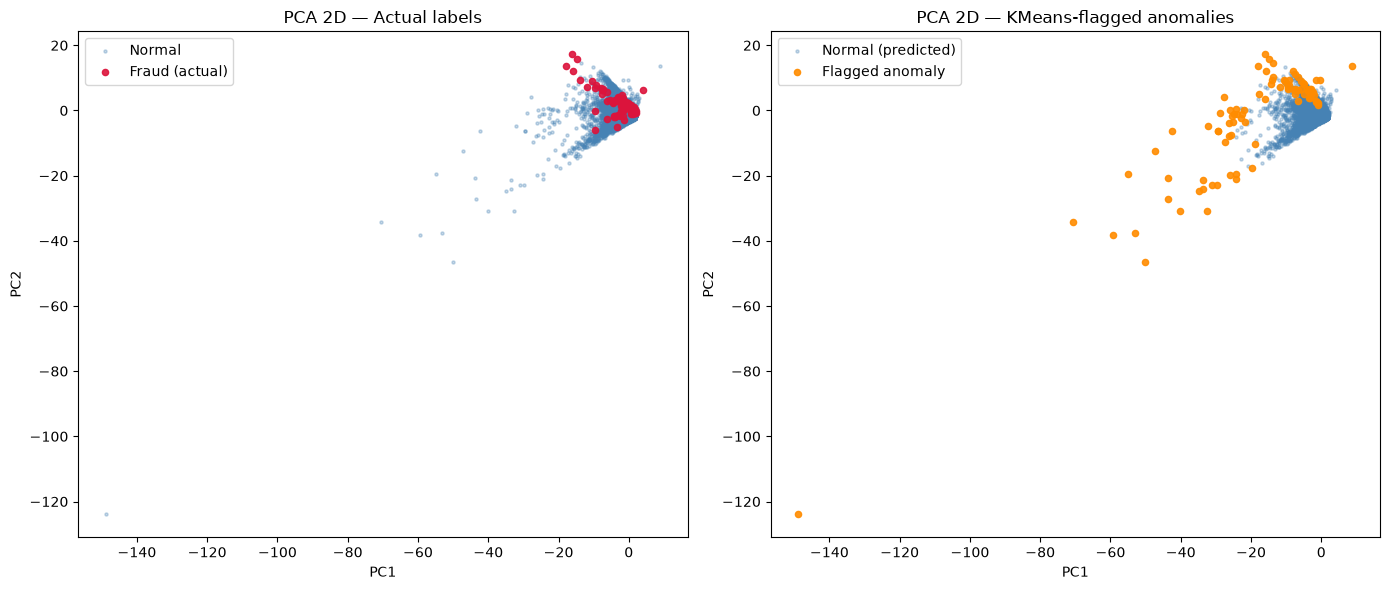

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test)
print("Explained variance ratio:", pca.explained_variance_ratio_,
      "| Total:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_test_pca[y_test==0, 0], X_test_pca[y_test==0, 1],
                s=5, alpha=0.3, label="Normal", color="steelblue")
axes[0].scatter(X_test_pca[y_test==1, 0], X_test_pca[y_test==1, 1],
                s=20, alpha=0.9, label="Fraud (actual)", color="crimson")
axes[0].set_title("PCA 2D — Actual labels")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].scatter(X_test_pca[kmeans_preds==0, 0], X_test_pca[kmeans_preds==0, 1],
                s=5, alpha=0.3, label="Normal (predicted)", color="steelblue")
axes[1].scatter(X_test_pca[kmeans_preds==1, 0], X_test_pca[kmeans_preds==1, 1],
                s=20, alpha=0.9, label="Flagged anomaly", color="darkorange")
axes[1].set_title("PCA 2D — KMeans-flagged anomalies")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_viz.png')
plt.show()


## 9. Deep learning — feedforward ANN

A small feedforward network with dropout for regularization, trained with class weights (same imbalance-handling idea as `class_weight="balanced"` above) and early stopping to avoid overfitting.


In [11]:
tf.random.set_seed(RANDOM_STATE)

ann = Sequential([
    Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(units=64, activation='relu'),
    Dropout(0.3),
    Dense(units=1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
ann.summary()

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)


d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9598 - loss: 0.8607 - precision: 0.0346 - recall: 0.8542 - val_accuracy: 0.9850 - val_loss: 0.0819 - val_precision: 0.0845 - val_recall: 0.8857
Epoch 2/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9635 - loss: 0.3885 - precision: 0.0398 - recall: 0.8980 - val_accuracy: 0.9909 - val_loss: 0.0355 - val_precision: 0.1330 - val_recall: 0.8857
Epoch 3/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9705 - loss: 0.3991 - precision: 0.0494 - recall: 0.9067 - val_accuracy: 0.9877 - val_loss: 0.0630 - val_precision: 0.1013 - val_recall: 0.8857
Epoch 4/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9630 - loss: 0.5322 - precision: 0.0399 - recall: 0.9125 - val_accuracy: 0.9957 - val_loss: 0.0245 - val_precision: 0.2439 - val_recall: 0.8571
Epoch 5/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9453 - loss: 0.6625 - precision: 0.0270 - recall: 0.9009 - val_accuracy: 0.9911

KeyboardInterrupt: 

In [ ]:
ann_probs = ann.predict(X_test).ravel()
ann_preds = (ann_probs >= 0.5).astype(int)

print(classification_report(y_test, ann_preds, target_names=["Normal", "Fraud"]))
ann_ap = average_precision_score(y_test, ann_probs)
print(f"PR-AUC: {ann_ap:.4f}")


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.22      0.84      0.35        95

    accuracy                           0.99     56746
   macro avg       0.61      0.92      0.67     56746
weighted avg       1.00      0.99      1.00     56746

PR-AUC: 0.7326


### Training curves (overfitting sanity check)

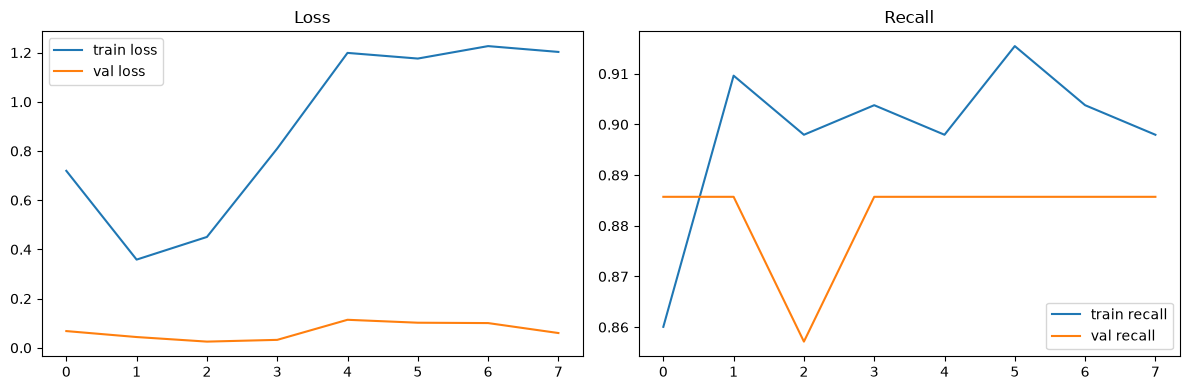

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["recall"], label="train recall")
axes[1].plot(history.history["val_recall"], label="val recall")
axes[1].set_title("Recall"); axes[1].legend()
plt.tight_layout()
plt.show()


## 10. Model comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KMeans (unsupervised)", "ANN"],
    "Precision": [precision_score(y_test, logreg_preds), precision_score(y_test, rf_preds),
                  precision_score(y_test, kmeans_preds), precision_score(y_test, ann_preds)],
    "Recall": [recall_score(y_test, logreg_preds), recall_score(y_test, rf_preds),
               recall_score(y_test, kmeans_preds), recall_score(y_test, ann_preds)],
    "F1": [f1_score(y_test, logreg_preds), f1_score(y_test, rf_preds),
           f1_score(y_test, kmeans_preds), f1_score(y_test, ann_preds)],
    "PR-AUC": [logreg_ap, rf_ap, kmeans_ap, ann_ap],
})
results.round(4)


,Model,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.0561,0.8737,0.1055,0.6720
1,Random Forest,0.9351,0.7579,0.8372,0.8070
2,KMeans (unsupervised),0.1789,0.1789,0.1789,0.1506
3,ANN,0.2210,0.8421,0.3501,0.7326


## 11. Key findings & limitations

- **Accuracy is not reported** as a headline metric — with a 0.17% fraud rate it's trivially high for any model and hides the real story.
- **Random Forest** is expected to give the best balance of precision and recall among the supervised models; Logistic Regression typically has high recall but low precision (many false alarms).
- **KMeans**, trained without any fraud labels, performs meaningfully above random but well below the supervised models — a fair trade-off given it needs no labeled data.
- **PCA visualization** only captures a small fraction of total variance in 2 dimensions, so it's a supporting sanity check, not primary evidence — the precision/recall/PR-AUC table is the real evaluation.
- **Feature interpretability is limited**: `V1`-`V28` are anonymized PCA components, so feature importance can only be discussed abstractly (e.g. "V14 mattered most"), not in business terms.
- **Next steps with more time:** threshold tuning per business cost (false positive vs. false negative cost), SHAP-based explainability on the Random Forest, and testing XGBoost/LightGBM as a stronger supervised baseline.


In [6]:
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

# SOM expects inputs scaled to [0,1], unlike the StandardScaler used for the other models
som_scaler = MinMaxScaler(feature_range=(0, 1))
X_train_som = som_scaler.fit_transform(X_train)
X_test_som = som_scaler.transform(X_test)

som = MiniSom(x=10, y=10, input_len=X_train_som.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=RANDOM_STATE)  # seeded, unlike the tutorial version
som.random_weights_init(X_train_som)
som.train_random(data=X_train_som, num_iteration=5000)

In [7]:
distance_map = som.distance_map()

# Top 10% highest-distance neurons = "outlier region" — computed, not read off a plot
threshold = np.percentile(distance_map, 90)
flagged_neurons = set(zip(*np.where(distance_map >= threshold)))
print(f"Flagged {len(flagged_neurons)} outlier neurons out of {10*10}")

Flagged 10 outlier neurons out of 100


In [8]:
som_preds = np.array([
    1 if som.winner(x) in flagged_neurons else 0
    for x in X_test_som
])

print(classification_report(y_test, som_preds, target_names=["Normal", "Fraud"]))

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96     56651
       Fraud       0.00      0.09      0.00        95

    accuracy                           0.93     56746
   macro avg       0.50      0.51      0.48     56746
weighted avg       1.00      0.93      0.96     56746



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KMeans (unsupervised)", "SOM (unsupervised)", "ANN"],
    "Precision": [precision_score(y_test, logreg_preds), precision_score(y_test, rf_preds),
                  precision_score(y_test, kmeans_preds), precision_score(y_test, som_preds),
                  precision_score(y_test, ann_preds)],
    "Recall": [recall_score(y_test, logreg_preds), recall_score(y_test, rf_preds),
               recall_score(y_test, kmeans_preds), recall_score(y_test, som_preds),
               recall_score(y_test, ann_preds)],
    "F1": [f1_score(y_test, logreg_preds), f1_score(y_test, rf_preds),
           f1_score(y_test, kmeans_preds), f1_score(y_test, som_preds),
           f1_score(y_test, ann_preds)],
})
results.round(4)